# Vessel State Prediction

## tl;dr

This notebook asks: **given the vessel's current state and environment, where will it be two seconds later?** It compares an interpretable kinematic baseline with a small residual gradient-boosting model using a trajectory-level temporal split.

> **Synthetic-accuracy limitation.** All results come from deterministic synthetic simulator data. The residual ML errors are very small relative to the kinematic baseline, but they must not be interpreted as real-world vessel-navigation accuracy. Real systems include sensor uncertainty, GPS/AIS error, vessel-specific hydrodynamics, actuator delays, harbor geometry, measurement noise, and changing environmental forecasts. This project demonstrates architecture and methodology—not certified navigation performance—and must not be used to control a real vessel.

## 1. Operational Problem

The berth is already assigned. Prediction is one component of a larger advisory loop: observe the current vessel and environment, predict the next position, compare it with the nominal approach, and recommend an abstract correction for a human operator to accept or override.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
ASSETS = ROOT / "assets"
ASSETS.mkdir(exist_ok=True)

from src.predictor import (
    FEATURES, TARGETS, fit_residual_model, kinematic_predict,
    ml_predict, prediction_metrics,
)

COLORS = {"baseline": "#7A7F87", "ml": "#146C94", "actual": "#D97706"}
plt.rcParams.update({
    "figure.figsize": (10, 5), "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.22, "font.size": 10,
})
RANDOM_SEED = 2026
DT_SECONDS = 2.0

## 2. Synthetic Vessel Data

### Key assumptions

- Coordinates are local metres: x east, y north.
- Heading is clockwise from north; speed is metres per second.
- Wind and current directions are synthetic flow-to directions.
- Every row contains the current state and the observed state one 2-second step later.
- Trajectory IDs are ordered synthetic episodes; later episodes are held out together to avoid future leakage.

In [2]:
vessel = pd.read_csv(ROOT / "data/sample/vessel_states.csv")
environment = pd.read_csv(ROOT / "data/sample/environment.csv").drop(columns="scenario")
data = vessel.merge(environment, on=["trajectory_id", "timestamp_s"], validate="one_to_one")

required = FEATURES + TARGETS
assert data[required].notna().all().all()
assert not data.duplicated(["trajectory_id", "timestamp_s"]).any()
assert (data.groupby("trajectory_id")["timestamp_s"].diff().dropna() == DT_SECONDS).all()

summary = pd.DataFrame({
    "measure": ["rows", "trajectories", "timestep (s)", "scenarios"],
    "value": [len(data), data.trajectory_id.nunique(), DT_SECONDS, data.scenario.nunique()],
})
display(summary)
display(data[["trajectory_id", "timestamp_s"] + required].head(3))

,measure,value
0,rows,4138.0
1,trajectories,36.0
2,timestep (s),2.0
3,scenarios,3.0


,trajectory_id,timestamp_s,x_position_m,y_position_m,heading_deg,speed_mps,yaw_rate_deg_s,distance_to_berth_m,cross_track_error_m,wind_speed_mps,wind_direction_deg,current_speed_mps,current_direction_deg,wave_height_m,previous_action,recommended_action,next_x_position_m,next_y_position_m
0,SYNTH_000,0.0,-903.172490,-339.037715,57.838301,5.348943,0.000,964.710899,2.354125,2.745623,212.994975,0.154135,44.019572,0.250000,MAINTAIN,CORRECT_STARBOARD,-893.908090,-333.399151
1,SYNTH_000,2.0,-893.908090,-333.399151,58.742608,5.345731,0.440,954.058000,2.913559,2.546885,213.355017,0.154858,44.096590,0.256313,CORRECT_STARBOARD,CORRECT_STARBOARD,-884.468024,-327.914828
2,SYNTH_000,4.0,-884.468024,-327.914828,60.013478,5.344705,0.638,943.298372,3.253807,2.889526,213.710972,0.155538,44.170602,0.262608,CORRECT_STARBOARD,CORRECT_STARBOARD,-874.969842,-322.734913


## 3. Environment and Disturbances

Wind speed/direction, current speed/direction, and wave height vary smoothly over each episode. Modest process noise prevents perfect trajectories while preserving continuity.

In [3]:
environment_ranges = data[[
    "wind_speed_mps", "wind_direction_deg", "current_speed_mps",
    "current_direction_deg", "wave_height_m"
]].agg(["min", "mean", "max"]).T.round(2)
display(environment_ranges)

,min,mean,max
wind_speed_mps,0.93,6.13,11.32
wind_direction_deg,0.04,232.81,359.99
current_speed_mps,0.04,0.31,0.66
current_direction_deg,0.00,154.81,360.00
wave_height_m,0.13,0.72,1.27


## 4. Prediction Target and Temporal Split

The targets are `next_x_position_m` and `next_y_position_m`. The first 75% of complete trajectories train the model; the final 25% form the test set. No rows from a held-out trajectory appear in training.

In [4]:
trajectory_ids = sorted(data.trajectory_id.unique())
split_index = int(len(trajectory_ids) * 0.75)
train_ids, test_ids = trajectory_ids[:split_index], trajectory_ids[split_index:]
train = data[data.trajectory_id.isin(train_ids)].copy()
test = data[data.trajectory_id.isin(test_ids)].copy()
assert set(train.trajectory_id).isdisjoint(test.trajectory_id)

display(pd.DataFrame({
    "split": ["Train (earlier episodes)", "Test (later episodes)"],
    "trajectories": [len(train_ids), len(test_ids)],
    "rows": [len(train), len(test)],
    "first_id": [train_ids[0], test_ids[0]],
    "last_id": [train_ids[-1], test_ids[-1]],
}))

,split,trajectories,rows,first_id,last_id
0,Train (earlier episodes),27,3106,SYNTH_000,SYNTH_026
1,Test (later episodes),9,1032,SYNTH_027,SYNTH_035


## 5. Kinematic Baseline

The baseline advances the current position using only current heading and speed. It intentionally ignores wind, current, noise, and non-linear residual motion.

In [5]:
actual = test[TARGETS].to_numpy()
baseline_predictions = kinematic_predict(test)
baseline_metrics = prediction_metrics(actual, baseline_predictions)
display(pd.Series(baseline_metrics, name="Kinematic baseline").to_frame().round(4))

,Kinematic baseline
mae_x_m,0.2484
mae_y_m,0.7471
position_rmse_m,0.9635
mean_position_error_m,0.8099
median_position_error_m,0.9439
p95_position_error_m,1.5665


## 6. ML Residual Predictor

A `HistGradientBoostingRegressor` predicts the x/y residual left after the kinematic estimate. This keeps the learned task small and interpretable: model wind, current, action, and simulator effects that simple motion does not capture.

In [6]:
model = fit_residual_model(train, random_state=RANDOM_SEED)
ml_predictions = ml_predict(model, test)
ml_metrics = prediction_metrics(actual, ml_predictions)

metrics = pd.DataFrame(
    [baseline_metrics, ml_metrics], index=["Kinematic baseline", "Residual ML predictor"]
).round(4)
display(metrics)

,mae_x_m,mae_y_m,position_rmse_m,mean_position_error_m,median_position_error_m,p95_position_error_m
Kinematic baseline,0.2484,0.7471,0.9635,0.8099,0.9439,1.5665
Residual ML predictor,0.0532,0.0472,0.0952,0.0796,0.0719,0.1569


## 7. Model Evaluation and Error Analysis

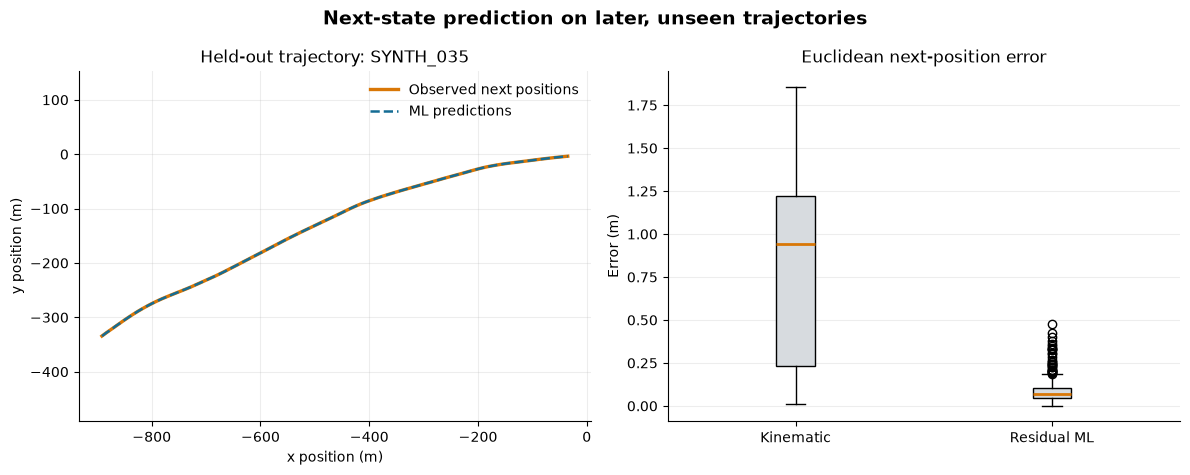

In [7]:
baseline_error = np.linalg.norm(actual - baseline_predictions, axis=1)
ml_error = np.linalg.norm(actual - ml_predictions, axis=1)

sample_id = test_ids[-1]
mask = test.trajectory_id.eq(sample_id).to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(actual[mask, 0], actual[mask, 1], color=COLORS["actual"], lw=2.4, label="Observed next positions")
axes[0].plot(ml_predictions[mask, 0], ml_predictions[mask, 1], "--", color=COLORS["ml"], lw=1.8, label="ML predictions")
axes[0].set(title=f"Held-out trajectory: {sample_id}", xlabel="x position (m)", ylabel="y position (m)")
axes[0].legend(frameon=False)
axes[0].axis("equal")

axes[1].boxplot([baseline_error, ml_error], tick_labels=["Kinematic", "Residual ML"], patch_artist=True,
                boxprops={"facecolor": "#D7DBDF"}, medianprops={"color": "#D97706", "linewidth": 2})
axes[1].set(title="Euclidean next-position error", ylabel="Error (m)")
axes[1].grid(axis="x", visible=False)
fig.suptitle("Next-state prediction on later, unseen trajectories", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(ASSETS / "vessel_next_position_prediction.png", dpi=170, bbox_inches="tight")
plt.show()

In [8]:
error_frame = test[["scenario"]].copy()
error_frame["Kinematic baseline"] = baseline_error
error_frame["Residual ML predictor"] = ml_error
scenario_errors = error_frame.groupby("scenario").agg(["mean", "median", lambda values: values.quantile(0.95)])
scenario_errors.columns = [f"{model_name} | {stat if stat != '<lambda_0>' else 'p95'}" for model_name, stat in scenario_errors.columns]
display(scenario_errors.round(3))

,Kinematic baseline | mean,Kinematic baseline | median,Kinematic baseline | p95,Residual ML predictor | mean,Residual ML predictor | median,Residual ML predictor | p95
scenario,,,,,,
calm,0.190,0.168,0.396,0.075,0.071,0.144
changing_wind_current,1.355,1.375,1.664,0.093,0.077,0.245
crosswind,0.987,0.984,1.250,0.071,0.068,0.132


## 8. Example Next-State Prediction

In [9]:
example_index = 25
example = test.iloc[example_index]
example_actual = actual[example_index]
example_ml = ml_predictions[example_index]
display(pd.DataFrame({
    "value": [example.trajectory_id, example.timestamp_s, example.x_position_m, example.y_position_m,
              example.wind_speed_mps, example.current_speed_mps,
              example_actual[0], example_actual[1], example_ml[0], example_ml[1],
              np.linalg.norm(example_actual - example_ml)],
}, index=["trajectory", "timestamp_s", "current_x_m", "current_y_m", "wind_mps", "current_mps",
          "actual_next_x_m", "actual_next_y_m", "predicted_next_x_m", "predicted_next_y_m", "position_error_m"]).round(3))

,value
trajectory,SYNTH_027
timestamp_s,50.0
current_x_m,-681.534062
current_y_m,-220.620547
wind_mps,1.985254
current_mps,0.074738
actual_next_x_m,-673.276784
actual_next_y_m,-216.29058
predicted_next_x_m,-673.395384
predicted_next_y_m,-216.198631


## 9. Key Takeaways

In [10]:
improvement = 100 * (1 - ml_metrics["position_rmse_m"] / baseline_metrics["position_rmse_m"])
display(Markdown(
    f"- The residual ML model reduced held-out position RMSE from **{baseline_metrics['position_rmse_m']:.3f} m** "
    f"to **{ml_metrics['position_rmse_m']:.3f} m** ({improvement:.1f}% lower).  \n"
    f"- Its median next-position error was **{ml_metrics['median_position_error_m']:.3f} m**, with a "
    f"**{ml_metrics['p95_position_error_m']:.3f} m** 95th percentile.  \n"
    "- This is evidence within a deterministic synthetic simulator, not evidence of real-vessel validity."
))

- The residual ML model reduced held-out position RMSE from **0.964 m** to **0.095 m** (90.1% lower).  
- Its median next-position error was **0.072 m**, with a **0.157 m** 95th percentile.  
- This is evidence within a deterministic synthetic simulator, not evidence of real-vessel validity.